In [26]:
from mreyemove import enable_logging
from mreyemove.constants import EYE_SIGNAL_CONFOUNDS
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO 
import pandas as pd

enable_logging("INFO")

dataset = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="raw"
)

HMC = [
    f"trans_{i}" for i in ("x", "y", "z")
]  
HMC.extend(
    [f"rot_{i}" for i in ("x", "y", "z")]
)
HMC.append("framewise_displacement")

# subject = "10"
dfs = []
for subject in dataset.subjects:
    for _, run, run_df in dataset.iter_run_events(subject=subject): 
        X = dataset.load_confounds(subject=subject, run=run, confound_names=HMC).reset_index(drop=True)
        df = (run_df[["subject", "run", "TR", "mreyemove" ]]).reset_index(drop=True)
        df = pd.concat((df, X), axis=1).reset_index(drop=True)
        dfs.append(df)
df = pd.concat(dfs, axis=0).reset_index(drop=True)

2026-02-03 14:31:22,437 | [INFO] | SleepMReye.sleepmreye.sleep_mrio: Skipping subject 09
2026-02-03 14:31:22,445 | [INFO] | SleepMReye.sleepmreye.sleep_mrio: Skipping subject 01
2026-02-03 14:31:22,467 | [INFO] | SleepMReye.sleepmreye.sleep_mrio: Skipping subject 07
2026-02-03 14:31:22,471 | [INFO] | SleepMReye.sleepmreye.sleep_mrio: Removing subject 02 without sleep sessions
2026-02-03 14:31:22,481 | [INFO] | SleepMReye.sleepmreye.sleep_mrio: Removing subject 21 without sleep sessions
2026-02-03 14:31:22,481 | [INFO] | SleepMReye.sleepmreye.sleep_mrio: Skipping subject 12


In [28]:
from statsmodels.tools.tools import add_constant
from statsmodels.regression.linear_model import OLS
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

run_means = df.groupby(['subject', 'run']).mean().reset_index()
fd_only = run_means[HMC]["framewise_displacement"]
hmc_only = run_means[HMC].drop(columns="framewise_displacement")
all_ps = run_means[HMC]

for x in (hmc_only, all_ps, fd_only):
# for x in (run_means[EYE_SIGNAL_CONFOUNDS],):
    y = run_means["mreyemove"]
    X = scaler.fit_transform(X)
    X = add_constant(x)

    
    model = OLS(y, X)
    
    result = model.fit()    
    print(result.rsquared)
# print(result.summary())

0.06476887207369375
0.2957638482426588
0.2782005003239668


In [25]:
run_means

,subject,run,TR,mreyemove,trans_x,trans_y,trans_z,trans_x_derivative1,trans_y_derivative1,trans_z_derivative1,rot_x,rot_y,rot_z,rot_x_derivative1,rot_y_derivative1,rot_z_derivative1
0,03,1,214.0,0.004944,0.169723,0.154352,1.135973,0.000666,0.000661,0.005542,-0.007905,0.004852,0.000775,-0.000036,3.158739e-05,3.159914e-06
1,03,2,214.0,0.005695,0.049074,0.076361,0.635738,0.000346,0.000978,0.003169,-0.000733,0.003228,0.000048,-0.000009,1.504588e-05,2.797257e-06
2,03,3,214.0,0.005324,-0.052963,0.035190,0.148319,-0.000053,0.000078,-0.000009,-0.000061,-0.000411,-0.000511,-0.000006,4.968384e-07,2.554275e-07
3,03,4,214.0,0.004862,0.055643,0.073426,0.344991,-0.000089,-0.000034,0.000024,-0.002971,0.002127,0.000381,0.000003,-3.651253e-06,-1.150903e-06
4,03,5,214.0,0.003715,0.003571,-0.085238,0.031370,-0.000008,0.000064,-0.001442,0.001703,-0.000782,0.000329,0.000024,9.895962e-07,4.397587e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,33,3,214.0,0.004283,0.001798,0.154801,0.439362,-0.000110,0.001180,0.002117,-0.001977,0.000069,0.000698,-0.000009,-2.934007e-06,1.340007e-06
166,33,4,214.0,0.003917,0.002785,-0.068324,-0.078263,0.000064,-0.000219,-0.000346,-0.001291,-0.000565,0.000246,-0.000005,-1.079682e-06,1.586536e-06
167,33,5,214.0,0.004831,-0.008383,0.088702,0.162435,-0.000213,0.000636,0.000986,0.001037,-0.000773,0.000292,0.000006,-4.815295e-06,9.010182e-07
168,33,6,214.0,0.010784,0.035082,0.154114,0.527962,0.000274,0.000730,0.001812,-0.011744,0.002189,0.001058,-0.000033,1.337527e-05,6.179380e-06


In [43]:
import numpy as np
results_per_run = []

confounds_to_check = list(EYE_SIGNAL_CONFOUNDS)
confounds_to_check.append("framewise_displacement")

for subject in dataset.subjects:
    for subject, run, _ in dataset.iter_run_events(subject):
        # Load motion parameters
        motion_params = dataset.load_confounds(subject, run, 
            confound_names=confounds_to_check)
        
        # Load eye signal
        eye_signal, _ = dataset.load_eye_move(subject, run, desc_add="clean-voxels")
        
        # Compute correlation for each parameter
        run_corrs = {}
        for param in motion_params.columns:
            corr = np.corrcoef(np.abs(motion_params[param]), eye_signal)[0, 1]
            run_corrs[param] = corr
        
        results_per_run.append(run_corrs)

# Average correlations across runs
results_df = pd.DataFrame(results_per_run)
mean_corrs = results_df.mean().sort_values(key=abs, ascending=False)

print("Mean correlation with eye signal:")
print(mean_corrs)

Mean correlation with eye signal:
framewise_displacement    0.201713
rot_x_derivative1         0.174605
rot_z_derivative1         0.171917
trans_z_derivative1       0.165030
rot_y_derivative1         0.156107
trans_x_derivative1       0.147229
trans_y_derivative1       0.115803
trans_y                   0.087743
rot_x                     0.077938
trans_z                   0.061584
rot_z                     0.061174
trans_x                   0.058474
rot_y                     0.043533
dtype: float64


In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd

results = []

for subject in dataset.subjects:
    for subject, run, _ in dataset.iter_run_events(subject):
        # Load data
        motion_params = dataset.load_confounds(subject, run, 
            confound_names=confounds_to_check)
        eye_signal, _ = dataset.load_eye_move(subject, run, desc_add="clean")
        
        # Model 1: FD only
        FD = motion_params['framewise_displacement'].values.reshape(-1, 1)
        model1 = LinearRegression().fit(FD, eye_signal)
        r2_fd = model1.score(FD, eye_signal)
        
        # Model 2: All absolute derivatives
        derivatives = [col for col in motion_params.columns if 'derivative' in col and col != "framewise_displacement"]
        
        abs_derivs = motion_params[derivatives].abs()
        model2 = LinearRegression().fit(abs_derivs, eye_signal)
        r2_abs_derivs = model2.score(abs_derivs, eye_signal)
        
        model_3 = LinearRegression().fit(motion_params[derivatives], eye_signal)
        r2_derivs = model_3.score(motion_params[derivatives], eye_signal)
        
        model_4 = LinearRegression().fit(motion_params[confounds_to_check], eye_signal)
        r2_all = model_4.score(motion_params[confounds_to_check], eye_signal)
        
        non_derivatives = [col for col in motion_params.columns if 'derivative' not in col]
        model_5 = LinearRegression().fit(motion_params[non_derivatives], eye_signal)
        r2_noderivs = model_5.score(motion_params[non_derivatives], eye_signal)
        
        model_6 = LinearRegression().fit(motion_params[confounds_to_check].abs(), eye_signal)
        r2_all_abs = model_6.score(motion_params[confounds_to_check].abs(), eye_signal)
        
        results.append({
            'subject': subject,
            'run': run,
            'r2_fd': r2_fd,
            'r2_abs_derivs': r2_abs_derivs,
            'r2_derivs': r2_derivs,
            'r2_all': r2_all,
            'r2_all_abs': r2_all_abs,
            "r2_noderivs": r2_noderivs,
        })

results_df = pd.DataFrame(results)
print(f"Mean R² - FD only: {results_df['r2_fd'].mean():.3f}")
print(f"Mean R² - All abs derivatives: {results_df['r2_abs_derivs'].mean():.3f}")
print(f"Mean R² - All derivatives: {results_df['r2_derivs'].mean():.3f}")
print(f"Mean R² - All: {results_df['r2_all'].mean():.3f}")
print(f"Mean R² - All Abs: {results_df['r2_all_abs'].mean():.3f}")
print(f"Mean R² - No Derivs: {results_df['r2_noderivs'].mean():.3f}")
# print(f"Difference: {(results_df['r2_abs_derivs'] - results_df['r2_fd']).mean():.3f}")

# Paired t-test
# from scipy.stats import ttest_rel
# t, p = ttest_rel(results_df['r2_fd'], results_df['r2_abs_derivs'])
# print(f"\nPaired t-test: t={t:.3f}, p={p:.4f}")

Mean R² - FD only: -0.000
Mean R² - All abs derivatives: 0.042
Mean R² - All derivatives: 0.027
Mean R² - All: 0.036
Mean R² - All Abs: 0.072
Mean R² - No Derivs: -0.000


In [1]:
# Look at mean FD across states
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO 

import pandas as pd
import numpy as np

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean-with-fd-clamped"
)


In [2]:
import pandas as pd
import numpy as np

# Collect FD values labeled by sleep stage at each TR
motion_by_stage = []

for subject, run, run_df in mrio.iter_run_events(run_inclusion=True):
    # if subject == "28" and run == "6":
    #     print(run_df["state"].unique())
    #     print(mrio.run_inclusion_condition(run_df))
            
    print(f"{subject}, {run}" ,run_df.state.unique())
    # break

03, 1 ['2' '1']
03, 2 ['2' '1']
03, 3 ['2' '1']
03, 4 ['2' '1']
03, 5 ['2' 'W']
03, 6 ['1' '2' 'W']
03, 7 ['2' '1' 'W']
03, 8 ['2' '1']
04, 1 ['W' '1' '2']
04, 2 ['W' '1' '2']
04, 4 ['W' '1' '2']
04, 5 ['W' '1' '2']
04, 6 ['W' '1' '2']
04, 7 ['W' '1']
05, 1 ['W']
05, 2 ['W']
05, 3 ['W' '1' '2']
05, 4 ['W']
05, 5 ['W' '1']
05, 6 ['W']
06, 1 ['W']
06, 2 ['W']
06, 3 ['W' '1' '2']
06, 4 ['W']
08, 1 ['W']
08, 2 ['W']
08, 3 ['W']
08, 4 ['W']
08, 5 ['W']
08, 6 ['1' 'W']
08, 7 ['W']
10, 1 ['W' '1']
10, 2 ['W' '1' '2']
10, 3 ['W' '1' '2']
10, 4 ['W' '1' '2']
10, 5 ['W' '1']
10, 6 ['W']
11, 2 ['1' 'W']
11, 4 ['1' 'W']
13, 1 ['1' 'W']
13, 2 ['W']
13, 3 ['W']
13, 4 ['W']
14, 1 ['1' 'W']
14, 2 ['1' '2']
14, 3 ['1' '2']
14, 4 ['1' '2' 'W']
14, 5 ['W' '1']
14, 6 ['1' '2' 'W']
14, 7 ['2' 'W' '1']
15, 1 ['W' '1']
15, 2 ['W' '1']
15, 3 ['W' '1' '2']
15, 4 ['1' '2']
15, 5 ['1' '2' 'W']
15, 6 ['W' '1' '2']
16, 1 ['1' '2']
16, 2 ['1' '2']
16, 3 ['W' '1' '2']
16, 4 ['W' '1' '2']
16, 5 ['1' '2']
16, 6 ['2' '

In [3]:
import pandas as pd
import numpy as np

# Collect FD values labeled by sleep stage at each TR
motion_by_stage = []
runs = 0
for subject, run, run_df in mrio.iter_run_events():
    # Load FD timeseries (shape: n_TRs,)
    fd = mrio.load_confounds(subject=subject, run=run, 
                             confound_names=["framewise_displacement"])["framewise_displacement"].to_numpy()
    
    # Get sleep stage labels for each TR in this run
    # Assuming run_df has 'stage' column with labels like 'awake', 'N1', 'N2'
    stages = run_df['state'].values  # should be same length as fd
    
    # Pair each FD value with its sleep stage, to create a new df
    for fd_val, stage in zip(fd, stages):
        motion_by_stage.append({
            'subject': subject,
            'run': run,
            'state': stage,
            'fd': fd_val
        })
    runs +=1

df = pd.DataFrame(motion_by_stage)

# Compare mean FD across sleep stages
stage_comparison = df.groupby('state')['fd'].agg(['mean', 'median', 'std', 'count'])
print("\nMotion by sleep state:")
print(stage_comparison)

# Statistical test with mixed effects (accounting for subject clustering)
import statsmodels.formula.api as smf

model = smf.mixedlm("fd ~ C(state)", 
                     data=df, 
                     groups=df["subject"])
result = model.fit()
print("\n", result.summary())
print(runs)


Motion by sleep state:
           mean    median       std  count
state                                     
1      0.250266  0.146703  0.501723  21105
2      0.251814  0.176438  0.358698  12341
W      0.249667  0.137055  0.584358  33593

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: fd         
No. Observations: 67039   Method:             REML       
No. Groups:       27      Scale:              0.2579     
Min. group size:  854     Log-Likelihood:     -49779.2634
Max. group size:  3416    Converged:          Yes        
Mean group size:  2482.9                                 
---------------------------------------------------------
               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept       0.231    0.027  8.620 0.000  0.178  0.284
C(state)[T.2]  -0.030    0.006 -4.647 0.000 -0.043 -0.017
C(state)[T.W]   0.059    0.005 10.891 0.000  0.048  0.070
Group Var      

In [9]:
# Calculate subject-specific means for each state
subject_means = df.groupby(['subject', 'state'])['fd'].mean().reset_index()
subject_wide = subject_means.pivot(index='subject', columns='state', values='fd')

# Look at within-subject differences
print("Within-subject differences:")
print(f"W - N1: {(subject_wide['W'] - subject_wide['1']).mean():.4f}")
print(f"N1 - N2: {(subject_wide['1'] - subject_wide['2']).mean():.4f}")

Within-subject differences:
W - N1: 0.0750
N1 - N2: 0.0197


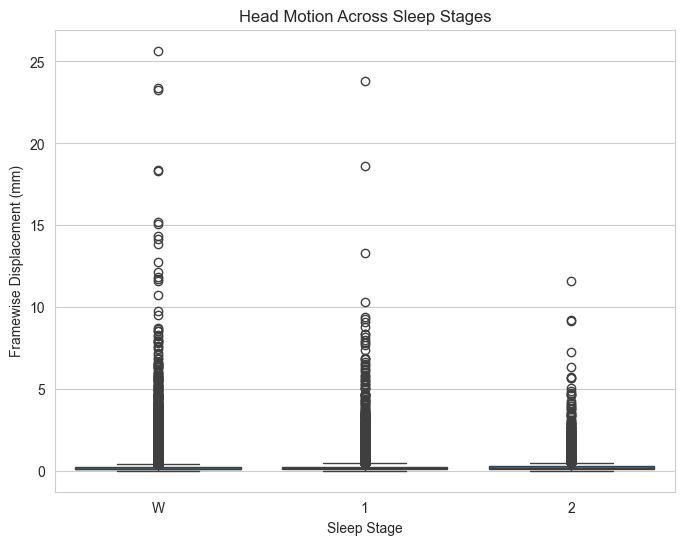

In [5]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='state', y='fd', order=['W', '1', '2'])
plt.ylabel('Framewise Displacement (mm)')
plt.xlabel('Sleep Stage')
plt.title('Head Motion Across Sleep Stages')
plt.show()